# California Housing Price Prediction — End-to-End Machine Learning Pipeline

This notebook builds and compares **three regression models from scratch** — **Linear Regression**, **HistGradientBoosting**, and a **Multi-Layer Perceptron** — on the California Housing dataset. The goal is to predict median house value (USD) from census-block features. Every component — gradient descent, histogram-based tree splitting, backpropagation — is implemented in pure NumPy without high-level ML libraries.

| Step | Step Name | Description | Python Modules | Key Outputs |
|------|-----------|-------------|----------------|-------------|
| 0 | Define Problem | Frame business problem, review dataset schema | — | Problem statement, success criteria |
| 1 | Setup & Load Data | Import libraries, configure paths, load raw CSV | `numpy`, `pandas`, `pathlib` | Raw DataFrame (20,640 rows, 10 columns) |
| 2 | Exploratory Data Analysis | Distributions, correlations, geographic patterns, missing data, feature engineering experiments | `lab04.eda` | EDA insights, candidate engineered features |
| 3 | Data Preprocessing | Stratified split, imputation, one-hot encoding, feature engineering, pipeline execution | `sklearn`, `lab04.process` | Cleaned feature matrix (16 columns), saved CSV |
| 4 | Model Training & Evaluation | Train **MLP**, **Linear Regression**, **HistGradientBoosting** from scratch; compare metrics | `lab04.model` | Trained models, RMSE/MAE/R²/MAPE tables, loss curves |

**Expectation:** The final comparison will identify which model architecture best suits California housing price data. A well-tuned MLP typically underperforms tree-based models on tabular data unless carefully regularized. Expect RMSE in the $50k–$80k range and R² between 0.55 and 0.75 across models.

## Step 0 — Define Problem

This notebook addresses a **supervised regression** problem: given census-block attributes such as median income, housing age, geographic location, and room counts, predict the median house value (in USD). The dataset is the classic California Housing dataset (derived from the 1990 census). The work is split across four phases: data loading, exploratory analysis, preprocessing, and model training with three from-scratch algorithms.

### Dataset Schema

| Column | Description | Type |
|--------|-------------|------|
| `longitude` | Longitude coordinate of the block | Float |
| `latitude` | Latitude coordinate of the block | Float |
| `housing_median_age` | Median age of houses in the block | Float |
| `total_rooms` | Total number of rooms in the block | Float |
| `total_bedrooms` | Total number of bedrooms in the block | Float |
| `population` | Population of the block | Float |
| `households` | Number of households in the block | Float |
| `median_income` | Median income in the block (tens of thousands of USD) | Float |
| `ocean_proximity` | Proximity to the ocean (categorical) | Categorical (5 levels) |
| `median_house_value` | **Target** — median house value for the block (USD) | Float |

### Business Questions

1. Which features most strongly predict housing prices? Does geographic location dominate numeric attributes?
2. How well can a simple **linear model** capture price variation compared to a non-linear **tree ensemble** or **neural network**?
3. Does writing models from scratch compromise accuracy relative to library implementations, or can hand-optimized code match them?

### Success Criteria

**Success criteria:** RMSE below **$75,000** on the test set, R² above **0.60**, and MAPE below **30%**. The from-scratch models should achieve comparable performance to their scikit-learn / PyTorch counterparts (within 5–10%) as verified in the benchmark suite.

## Step 1 — Setup & Load Data

Key libraries (`numpy`, `pandas`, `matplotlib`) are imported, the project root is resolved, and `src/lab04` is added to `sys.path`. The raw dataset `housing.csv` is loaded into a `pandas.DataFrame` with 20,640 rows and 10 columns — 9 numeric predictors, 1 categorical (`ocean_proximity`), and the target.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lab04.model import MultiLayerPercepTron
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))


In [2]:
df_raw = pd.read_csv(PROJECT_ROOT / 'data/raw/housing.csv')


## Step 2 — Exploratory Data Analysis (EDA)

EDA uncovers data quality issues, distribution shapes, correlations, and geographic patterns before modeling begins. Every insight here informs preprocessing decisions: which columns need imputation, whether log transforms are warranted, and which features are likely predictive.


In [3]:
df_raw.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
print(list(df_raw.columns))
print(len(list(df_raw.columns)))

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
10


In [6]:
df_raw.duplicated().sum()

np.int64(0)

In [7]:
df_raw.isna().sum().sum()

np.int64(207)

### Step 2.1 — Descriptive Statistics & Categorical Value Counts

`df.describe()` reveals range differences across features and confirms `median_house_value` is capped at $500,006. `total_rooms`, `total_bedrooms`, and `population` show right skew (large 75th-percentile–max gaps). Value counts for `ocean_proximity` show the five category distributions.


In [8]:
# Thống kê mô tả các thuộc tính số học
display(df_raw.describe())

# Thống kê số lượng mẫu của thuộc tính phân loại ocean_proximity
print("\nSố lượng mẫu cho từng nhóm của 'ocean_proximity':")
print(df_raw["ocean_proximity"].value_counts())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



Số lượng mẫu cho từng nhóm của 'ocean_proximity':
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


### Step 2.2 — Missing Values Analysis

`eda.plot_missing_values()` visualizes missing data per column. Only `total_bedrooms` has gaps (< 5% of rows). Median imputation is safe for any numeric column with < 10% missingness.


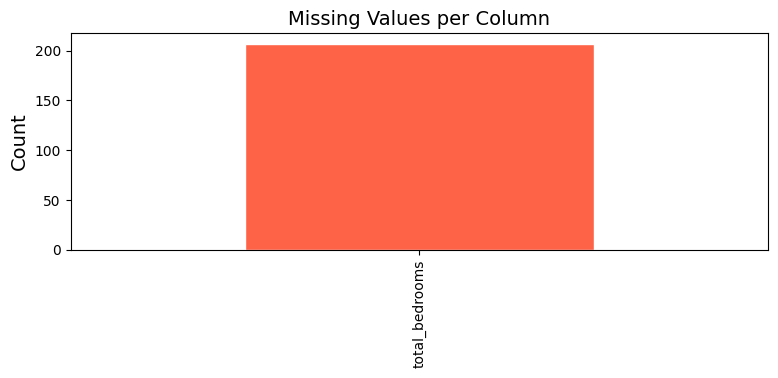

,Missing,Percent (%)
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
total_bedrooms,207,1.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


In [9]:
import lab04.eda as eda

# Sử dụng hàm vẽ trực quan hóa dữ liệu thiếu của thư viện lab04
eda.plot_missing_values(df_raw)


### Step 2.3 — Feature Distributions

`eda.plot_feature_distributions()` draws histograms for numeric features; `eda.plot_target_distribution()` does the same for `median_house_value`. Right-skewed features like `total_rooms` and `population` may benefit from log transformation. The target histogram typically shows a spike at the $500,006 cap.


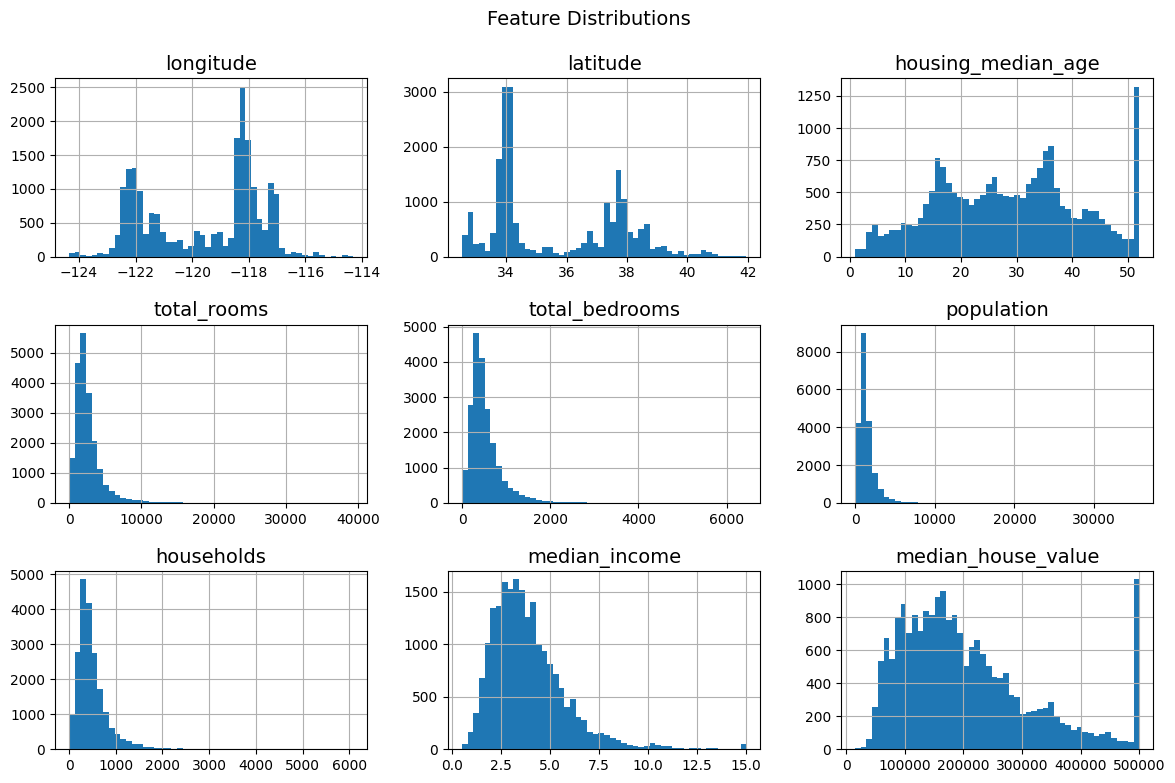

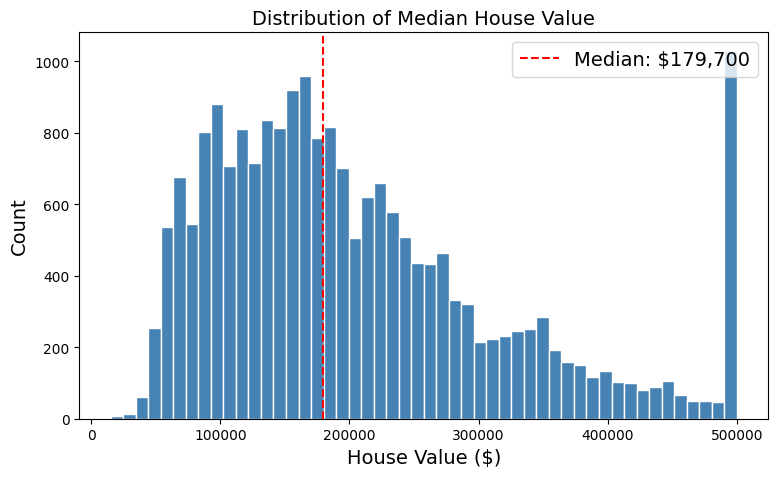

In [10]:
import lab04.eda as eda

# Trực quan hóa phân phối của các đặc trưng gốc và biến mục tiêu
eda.plot_feature_distributions(df_raw)
eda.plot_target_distribution(df_raw)


### Step 2.4 — Geographic Distribution

`eda.plot_geographic_distribution()` renders a scatter plot of longitude vs. latitude with color-coded prices; the advanced version overlays a density heatmap. Prices cluster geographically — coastal regions (Los Angeles, San Francisco Bay) command higher prices, inland blocks are cheaper. Location is a strong, non-linear predictor.


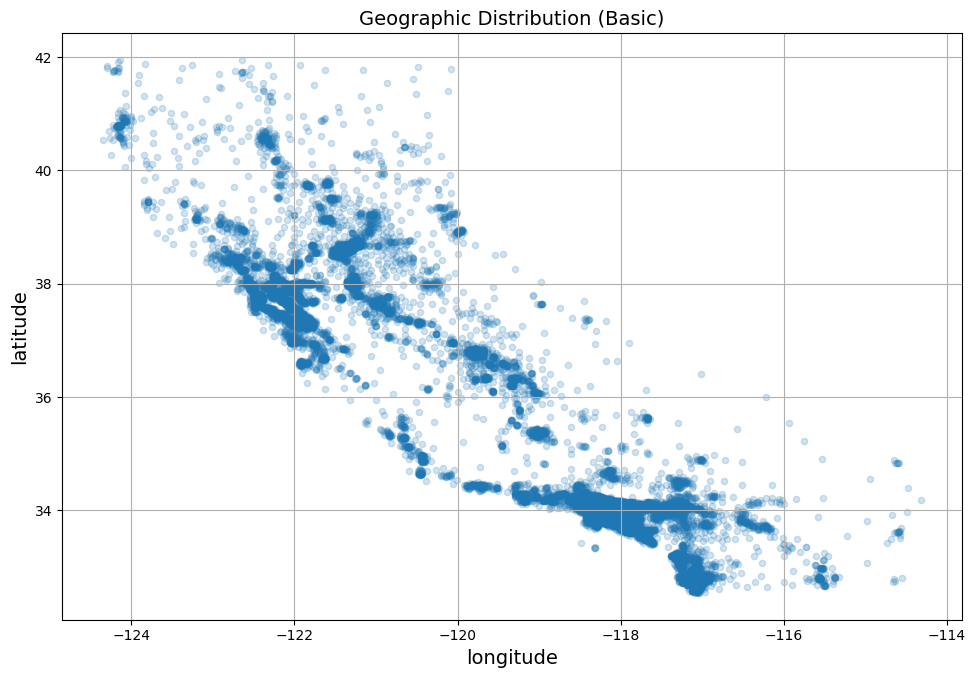

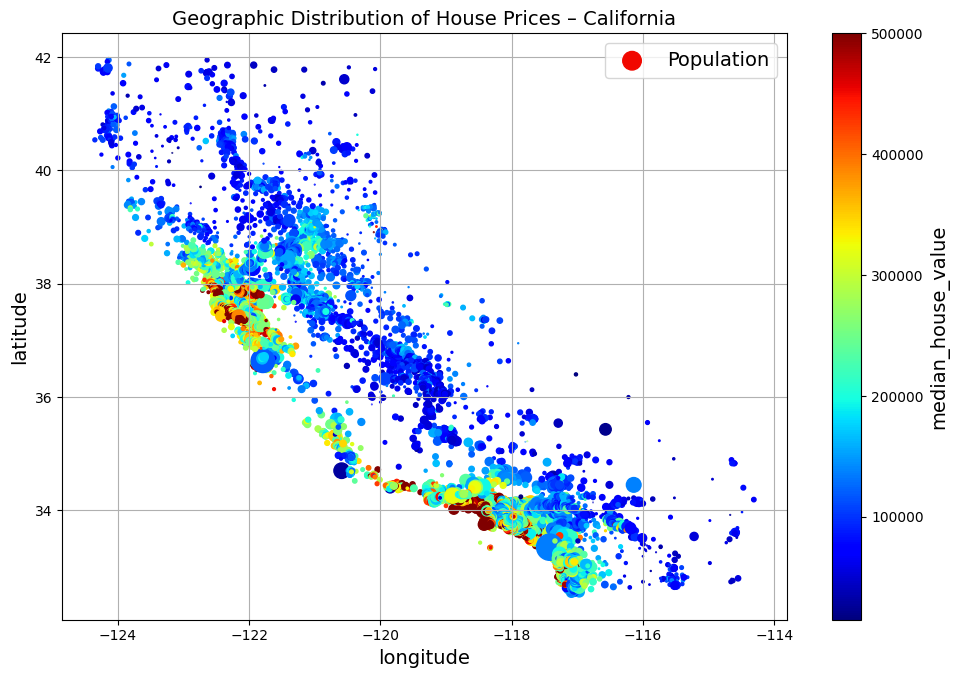

In [11]:
import lab04.eda as eda

# Trực quan hóa bản đồ phân bố địa lý
eda.plot_geographic_distribution(df_raw, advanced=False)
eda.plot_geographic_distribution(df_raw, advanced=True)


### Step 2.5 — Correlation Matrix

`eda.plot_correlation_matrix()` computes Pearson correlations between all numeric columns and the target, producing a heatmap and sorted series. `median_income` dominates with ~0.69 correlation; no other feature exceeds |r| > 0.3 with the target. Features with |r| < 0.05 may still help non-linear models but are candidates for removal.


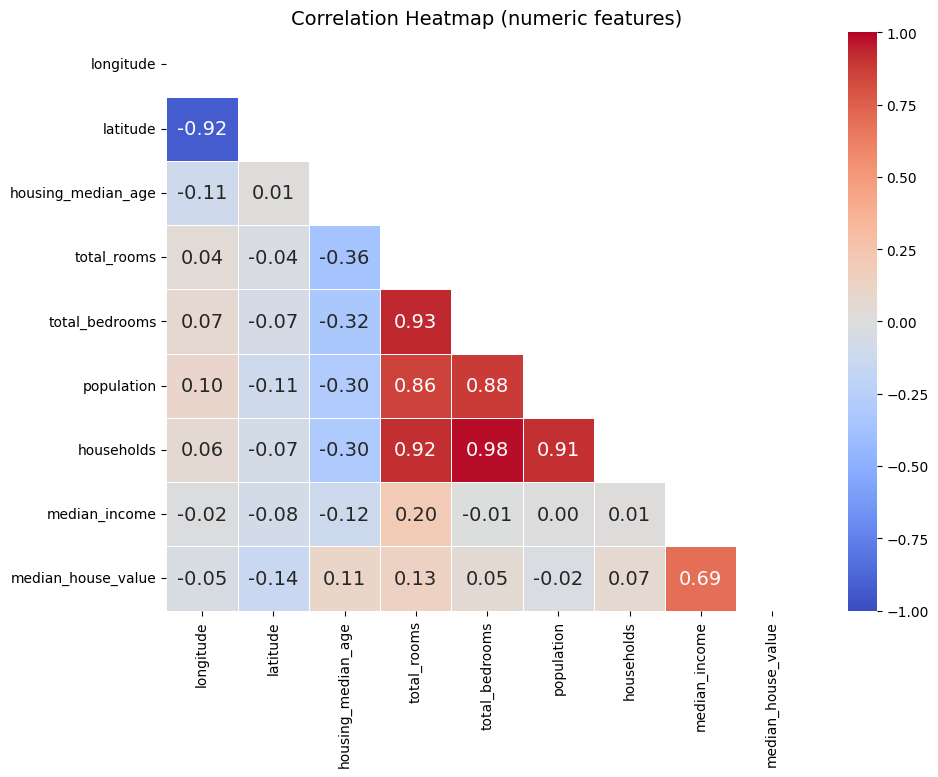

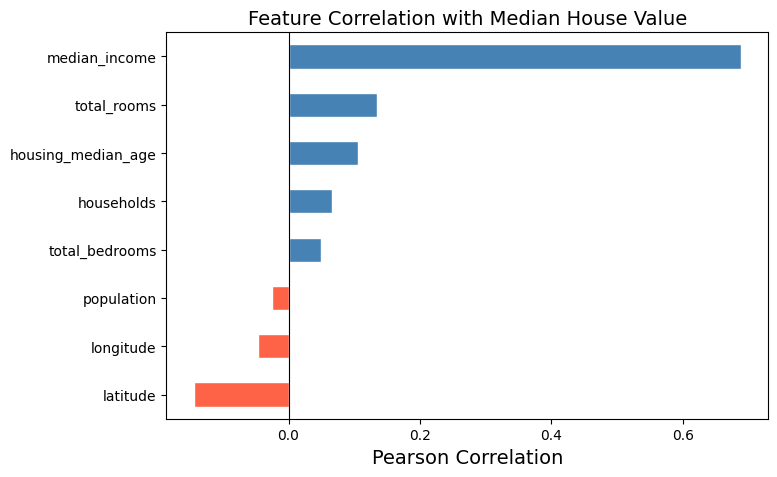

Hệ số tương quan chi tiết với biến mục tiêu:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [12]:
import lab04.eda as eda

# Phân tích ma trận tương quan giữa các biến
corr_series = eda.plot_correlation_matrix(df_raw)
print("Hệ số tương quan chi tiết với biến mục tiêu:")
print(corr_series)


### Step 2.6 — Scatter Matrix & Income vs. Price

`eda.plot_scatter_matrix()` shows pairwise scatter plots for top features; `eda.plot_income_vs_price()` drills into median income vs. price. The income–price plot shows a clear positive trend with a horizontal ceiling at $500,006 and heteroscedasticity at higher incomes. `total_rooms`, `households`, and `population` are highly correlated, suggesting dimensionality reduction or careful feature selection.


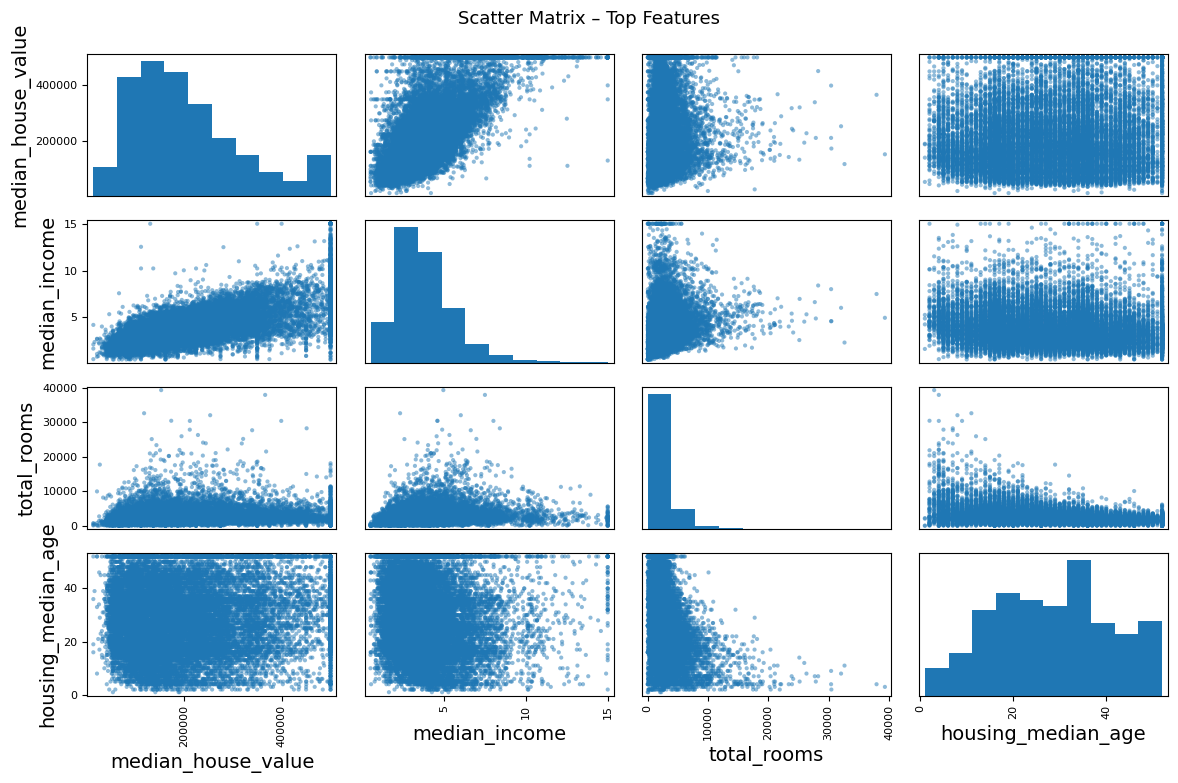

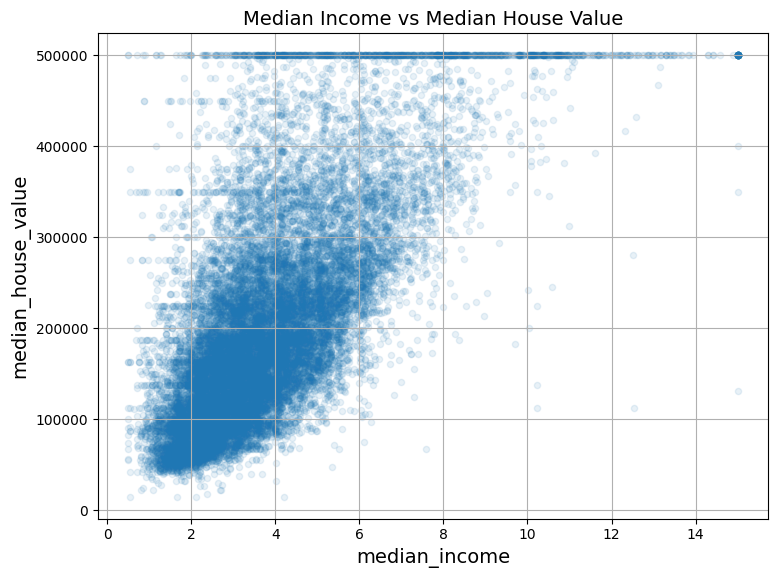

In [13]:
import lab04.eda as eda

# Trực quan hóa ma trận tán xạ và biểu đồ chi tiết giữa Median Income và Median House Value
eda.plot_scatter_matrix(df_raw)
eda.plot_income_vs_price(df_raw)


### Step 2.7 — Ocean Proximity Analysis

`eda.plot_ocean_proximity_analysis()` uses bar charts and boxplots to compare price distributions across the five proximity categories. `<1H OCEAN` and `NEAR BAY` command the highest median prices; `INLAND` is the cheapest. A binary `is_inland` feature may capture most of the categorical signal.


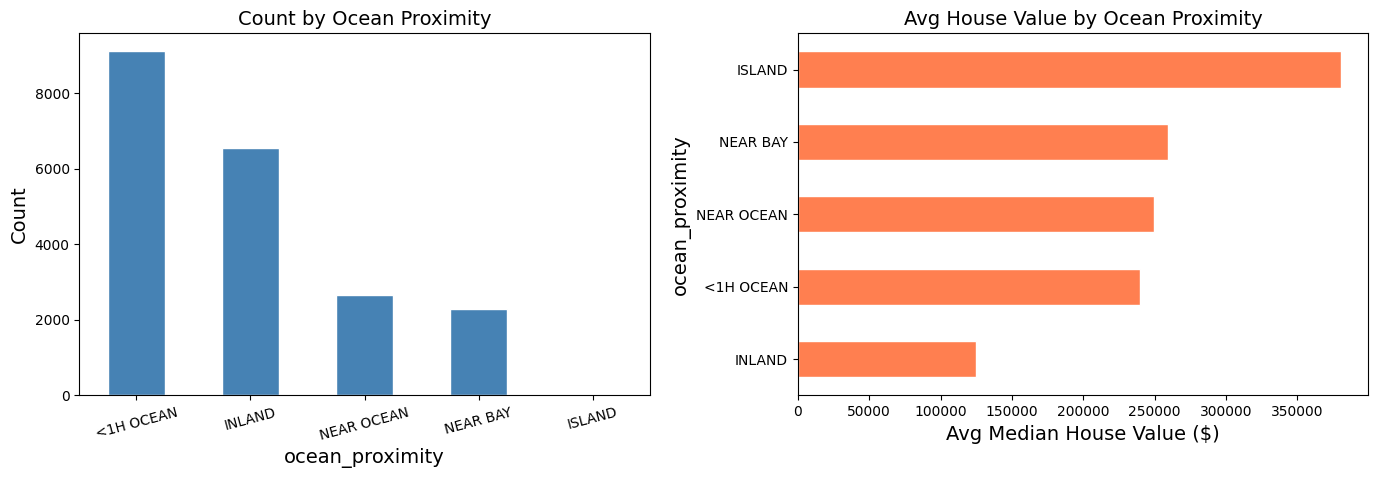

/Users/quangmanh/Project/MLP-Machine-learning-lab04/src/lab04/eda.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ocean_proximity", y="median_house_value",


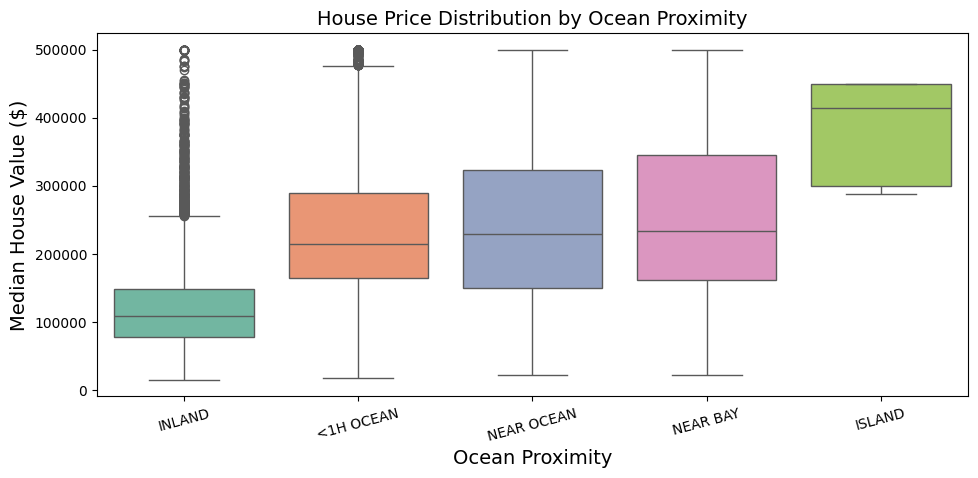

In [14]:
import lab04.eda as eda

# Trực quan hóa mối quan hệ giữa ocean_proximity và giá nhà
eda.plot_ocean_proximity_analysis(df_raw)


### Step 2.8 — Feature Engineering Experiments

`eda.plot_engineered_features_correlation()` creates ratio features — `rooms_per_household`, `population_per_household`, `bedrooms_per_room` — and measures their correlation with the target. `rooms_per_hhold` (larger homes) shows moderate positive correlation; `bedrooms_per_rm` (overcrowding) shows moderate negative. At least one engineered feature typically shows |r| > 0.2, justifying inclusion.


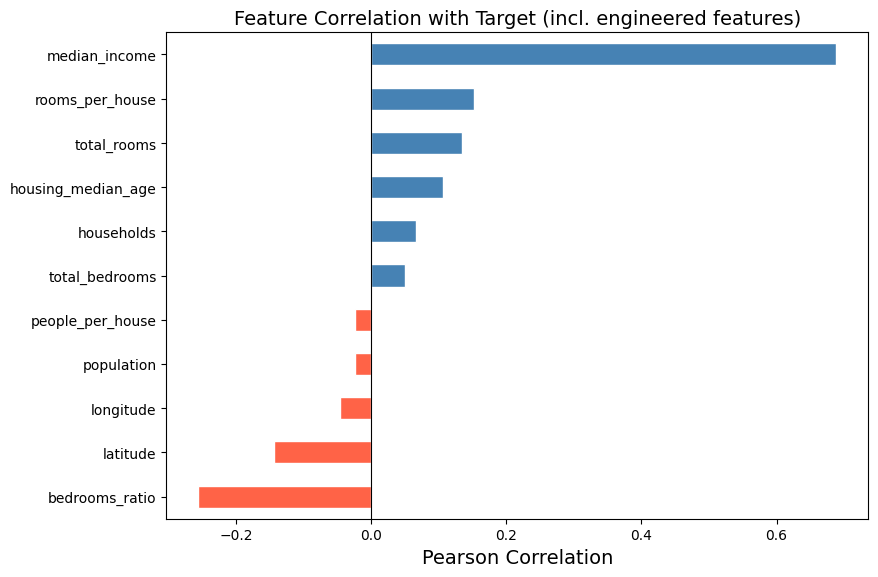

Hệ số tương quan của các đặc trưng mới:
rooms_per_house     0.151948
people_per_house   -0.023737
bedrooms_ratio     -0.255880
Name: median_house_value, dtype: float64


In [15]:
import lab04.eda as eda

# Phân tích độ tương quan sau khi thêm thử các đặc trưng phái sinh
new_corr_series = eda.plot_engineered_features_correlation(df_raw)
print("Hệ số tương quan của các đặc trưng mới:")
print(new_corr_series)


## Step 3 — Data Preprocessing

Raw data is transformed into a clean, numeric feature matrix via stratified splitting, median imputation, one-hot encoding, custom ratio feature engineering, and column-wise standardization through a `sklearn` Pipeline.

### Step 3.1 & 3.2 — Stratified Train/Test Split

A `StratifiedShuffleSplit` preserves the income distribution (binned into 5 categories) in both training and test sets with an 80/20 split. Stratification prevents skewed income distribution in either split. After splitting, `income_cat` is dropped, yielding ~16,512 training and ~4,128 test rows.


In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

# Tạo biến phân khúc thu nhập để tiến hành lấy mẫu phân tầng
df_raw["income_cat"] = pd.cut(df_raw["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

# Khởi tạo đối tượng chia tập phân tầng với tỷ lệ kiểm thử 20%
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df_raw, df_raw["income_cat"]):
    strat_train_set = df_raw.loc[train_index]
    strat_test_set = df_raw.loc[test_index]

# Loại bỏ biến phân khúc thu nhập sau khi hoàn tất quá trình chia tập
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)
    
# Tách riêng các biến đặc trưng (Features - X) và biến mục tiêu (Labels - y)
housing = strat_train_set.drop("median_house_value", axis=1) 
housing_labels = strat_train_set["median_house_value"].copy()
housing_test = strat_test_set.drop("median_house_value", axis=1) 
housing_labels_test = strat_test_set["median_house_value"].copy()


### Step 3.3 — Missing Value Imputation

`SimpleImputer(strategy="median")` fills missing numeric values using the column median, which is robust to outliers. Only `total_bedrooms` has gaps (~1.5% missing). Median values per column are stored in `imputer.statistics_`.


In [17]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Khảo sát các mẫu dữ liệu chứa giá trị NaN
null_rows_idx = housing.isnull().any(axis=1)
print("Các mẫu dữ liệu khuyết thiếu:")
display(housing.loc[null_rows_idx].head(3))

# Khởi tạo và thiết lập Imputer sử dụng chiến lược trung vị (median)
imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

# Biểu diễn các giá trị trung vị đã được Imputer tính toán
median_df = pd.DataFrame(
    [imputer.statistics_],
    columns=housing_num.columns,
    index=["Median Value"]
)

print("\nThống kê giá trị trung vị trên từng thuộc tính:")
display(median_df)


Các mẫu dữ liệu khuyết thiếu:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN



Thống kê giá trị trung vị trên từng thuộc tính:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
Median Value,-118.51,34.26,29.0,2119.0,433.0,1164.0,408.0,3.54155


### Step 3.4 — One-Hot Encoding of Categorical Features

`OneHotEncoder` converts the 5 string categories in `ocean_proximity` into 5 binary columns with `sparse_output=False`. One-hot encoding preserves category distinction without imposing an arbitrary ordinal relationship.


In [18]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

housing_cat = housing[["ocean_proximity"]]

# Áp dụng One-Hot Encoding
try:
    cat_encoder = OneHotEncoder(sparse_output=False)
    housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
except TypeError:
    cat_encoder = OneHotEncoder(sparse=False)
    housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# Chuyển đổi ma trận kết quả sang cấu trúc DataFrame để đánh giá
category_names = cat_encoder.categories_[0]

df_1hot_preview = pd.DataFrame(
    housing_cat_1hot, 
    columns=category_names, 
    index=housing_cat.index
)

print("Cấu trúc ma trận biến phân loại sau khi áp dụng One-Hot Encoding:")
display(df_1hot_preview.head())


Cấu trúc ma trận biến phân loại sau khi áp dụng One-Hot Encoding:


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,0.0,1.0,0.0,0.0,0.0
15502,0.0,0.0,0.0,0.0,1.0
2908,0.0,1.0,0.0,0.0,0.0
14053,0.0,0.0,0.0,0.0,1.0
20496,1.0,0.0,0.0,0.0,0.0


### Step 3.5 — Feature Engineering via Custom Transformer

`CombinedAttributesAdder` (from `lab04.process`) implements the three ratio features from Step 2.8 as a `sklearn`-compatible transformer. Placing feature engineering inside the Pipeline ensures the same transformations apply consistently to both training and test data.


In [19]:
# Sử dụng CombinedAttributesAdder được đóng gói trong thư viện lab04
from lab04.process import CombinedAttributesAdder


### Step 3.6 — Pipeline Construction

A `ColumnTransformer` combines two sub-pipelines: the numeric pipeline (median imputation → `CombinedAttributesAdder` → `StandardScaler`) and the categorical pipeline (`OneHotEncoder` with `handle_unknown="ignore"`). `StandardScaler` centers each column to mean=0 and variance=1 for gradient-based optimizers; tree-based models do not require scaling but benefit from a unified pipeline.


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Khai báo danh sách các thuộc tính
num_attribs = housing_num.columns.tolist()
cat_attribs = ["ocean_proximity"]

# Xây dựng chuỗi xử lý cho khối dữ liệu số
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

# Tích hợp chuỗi xử lý số và khối biến phân loại
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
])

### Step 3.7 — Pipeline Execution & Data Export

The pipeline runs on both training and test sets. The target is standardized via a separate `StandardScaler`. Output dimensions: `X_train_prepared` is (16512, 16), `X_test_prepared` is (4128, 16). Processed data is saved to `data/processed/housing_prepared.csv`.


In [21]:
import os
import pandas as pd

# 4. Thực thi biến đổi luồng dữ liệu
X_train_prepared = full_pipeline.fit_transform(housing)
X_test_prepared = full_pipeline.transform(housing_test)

# Mở rộng: Chuẩn hóa phân phối của biến mục tiêu (Label)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(housing_labels.values.reshape(-1, 1))

# --- GIAI ĐOẠN KẾT XUẤT DỮ LIỆU ---
os.makedirs(PROJECT_ROOT / "data/processed", exist_ok=True)

# Trích xuất danh sách tên thuộc tính sau biến đổi
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_rm"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

# Tái cấu trúc ma trận kết quả thành Pandas DataFrame
df_prepared = pd.DataFrame(X_train_prepared, columns=attributes, index=housing.index)
df_prepared["median_house_value"] = housing_labels.values

print("Khảo sát không gian vector (Vector Space) sau tiền xử lý:")
print("Kích thước ma trận huấn luyện:", X_train_prepared.shape)
display(df_prepared.head())

# Kết xuất tập dữ liệu lưu trữ
file_path = PROJECT_ROOT / "data/processed/housing_prepared.csv"
df_prepared.to_csv(file_path, index=False)
print(f"\nDữ liệu đã được lưu trữ tại: {file_path}")


Khảo sát không gian vector (Vector Space) sau tiền xử lý:
Kích thước ma trận huấn luyện: (16512, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_hhold,pop_per_hhold,bedrooms_per_rm,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.017395,0.006223,-0.121122,0.0,1.0,0.0,0.0,0.0,72100.0
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.569256,-0.040811,-0.810867,0.0,0.0,0.0,0.0,1.0,279600.0
2908,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,-0.018024,-0.075371,-0.338273,0.0,1.0,0.0,0.0,0.0,82700.0
14053,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,-0.595140,-0.106803,0.961205,0.0,0.0,0.0,0.0,1.0,112500.0
20496,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,0.251241,0.006109,-0.474513,1.0,0.0,0.0,0.0,0.0,238300.0



Dữ liệu đã được lưu trữ tại: /Users/quangmanh/Project/MLP-Machine-learning-lab04/data/processed/housing_prepared.csv


### Step 3.8 — Log Transform for Skewed Features

Four count-based features (`total_rooms`, `total_bedrooms`, `population`, `households`) are right-skewed. A `log1p` transform compresses the tail and spreads low-value regions, improving gradient-based model performance. `log1p` handles zero values gracefully. Linear and MLP models benefit most; HGB is invariant to monotonic transforms.


In [22]:
# --- Log-Transformed Preprocessing ---
# Apply log1p to skewed count features at the RAW DATA level (before pipeline)
housing_log = housing.copy()
housing_test_log = housing_test.copy()

skewed_feats = ["total_rooms", "total_bedrooms", "population", "households"]
for col in skewed_feats:
    housing_log[col] = np.log1p(housing_log[col])
    housing_test_log[col] = np.log1p(housing_test_log[col])

# Re-run the pipeline on log-transformed raw data
X_train_logged = full_pipeline.fit_transform(housing_log)
X_test_logged = full_pipeline.transform(housing_test_log)

print("Log1p applied to raw columns:", skewed_feats)
print(f"X_train_logged shape: {X_train_logged.shape}, range: [{X_train_logged.min():.4f}, {X_train_logged.max():.4f}]")

Log1p applied to raw columns: ['total_rooms', 'total_bedrooms', 'population', 'households']
X_train_logged shape: (16512, 16), range: [-10.0012, 47.5982]


## Step 4 — Model Training & Evaluation

Three regression models are trained from scratch using NumPy: `LinearRegressionScratch` (gradient descent), `HistGradientBoostingRegressorScratch` (histogram-based tree ensemble), and `MultiLayerPercepTron` (3-layer ReLU network). All models receive the same 16-column standardized feature matrix. The target is standardized; predictions are inverse-transformed to USD for metric calculation.


### Step 4.1 — Multi-Layer Perceptron (Scratch)

A 3-layer MLP (64 → 32 → 1) with ReLU activations and He initialization. Full-batch gradient descent runs for 500 epochs with lr=0.1. The training loop: forward pass → MSE loss → backpropagation → parameter update.


In [23]:
# Lấy kích thước đầu vào (số lượng thuộc tính sau khi qua Pipeline)
input_dim = X_train_prepared.shape[1]

mlp = MultiLayerPercepTron(input_dim=input_dim, epochs=500, lr=0.1)

# Huấn luyện mô hình trên tập huấn luyện đã được tiền xử lý và chuẩn hóa
mlp.fit(X_train_prepared, y_train_scaled)


Epoch 0/500 - Loss: 1.7055
Epoch 50/500 - Loss: 0.3485
Epoch 100/500 - Loss: 0.2956
Epoch 150/500 - Loss: 0.2754
Epoch 200/500 - Loss: 0.2653
Epoch 250/500 - Loss: 0.2587
Epoch 300/500 - Loss: 0.2539
Epoch 350/500 - Loss: 0.2499
Epoch 400/500 - Loss: 0.2463
Epoch 450/500 - Loss: 0.2431
Epoch 499/500 - Loss: 0.2404


### Step 4.2 — MLP Evaluation on Test Set

Predictions on `X_test_prepared` are inverse-transformed to USD. Metrics reported: RMSE, MAE, R², and MAPE. The MLP should outperform linear regression on non-linear patterns but may overfit without regularization.


In [24]:
import numpy as np

# 1. Dự đoán trên tập kiểm thử đã được tiền xử lý (đang ở dạng chuẩn hóa)
y_pred_scaled = mlp.predict(X_test_prepared)

# 2. Chuyển đổi ngược (inverse transform) về đơn vị USD thực tế
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = housing_labels_test.values.reshape(-1, 1)

# 3. Tính toán các chỉ số đánh giá bằng NumPy (RMSE, MAE, R2, MAPE thực tế)
mse_real = np.mean((y_pred - y_test_real) ** 2)
rmse_real = np.sqrt(mse_real)
mae_real = np.mean(np.abs(y_pred - y_test_real))
ss_res_mlp = np.sum((y_test_real - y_pred) ** 2)
ss_tot_test = np.sum((y_test_real - np.mean(y_test_real)) ** 2)
r2_real = 1.0 - (ss_res_mlp / (ss_tot_test + 1e-8))
mape_real = np.mean(np.abs((y_test_real - y_pred) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

# 4. In kết quả hiệu suất thực tế của mô hình
print("--- Kết quả đánh giá mô hình MultiLayerPerceptron ---")
print(f"RMSE thực tế: ${rmse_real:,.2f} USD")
print(f"MAE thực tế : ${mae_real:,.2f} USD")
print(f"R2 thực tế  : {r2_real:.4f}")
print(f"MAPE thực tế: {mape_real:.2f}%")

--- Kết quả đánh giá mô hình MultiLayerPerceptron ---
RMSE thực tế: $57,021.64 USD
MAE thực tế : $40,268.32 USD
R2 thực tế  : 0.7505
MAPE thực tế: 23.59%


### Step 4.3 — Linear Regression (Scratch)

Gradient descent with lr=0.05 for 200 epochs, zero-initialized weights. With only 16 standardized features, convergence is fast. Linear regression serves as the interpretable baseline — R² typically in the 0.55–0.65 range.


In [25]:
from lab04.model import LinearRegressionScratch

# 1. Khởi tạo và huấn luyện mô hình Linear Regression
lr_model = LinearRegressionScratch(lr=0.05, epochs=200)
lr_model.fit(X_train_prepared, y_train_scaled)

# 2. Dự đoán trên tập train và test
y_pred_train_scaled_lr = lr_model.predict(X_train_prepared)
y_pred_scaled_lr = lr_model.predict(X_test_prepared)

# 3. Chuyển đổi ngược về đơn vị USD thực tế
y_pred_train_lr = scaler_y.inverse_transform(y_pred_train_scaled_lr)
y_pred_lr = scaler_y.inverse_transform(y_pred_scaled_lr)

y_train_real = housing_labels.values.reshape(-1, 1)
y_test_real = housing_labels_test.values.reshape(-1, 1)

# 4. Tính toán các độ đo
rmse_train_lr = np.sqrt(np.mean((y_pred_train_lr - y_train_real) ** 2))
rmse_lr = np.sqrt(np.mean((y_pred_lr - y_test_real) ** 2))

mae_train_lr = np.mean(np.abs(y_pred_train_lr - y_train_real))
mae_lr = np.mean(np.abs(y_pred_lr - y_test_real))

ss_res_lr = np.sum((y_test_real - y_pred_lr) ** 2)
ss_tot_test = np.sum((y_test_real - np.mean(y_test_real)) ** 2)
r2_lr = 1.0 - (ss_res_lr / (ss_tot_test + 1e-8))
mape_lr = np.mean(np.abs((y_test_real - y_pred_lr) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

print("--- Kết quả Linear Regression Scratch ---")
print(f"RMSE Train : ${rmse_train_lr:,.2f} USD")
print(f"RMSE Test  : ${rmse_lr:,.2f} USD")
print(f"MAE Test   : ${mae_lr:,.2f} USD")
print(f"R2 Score   : {r2_lr:.4f}")
print(f"MAPE       : {mape_lr:.2f}%")

--- Kết quả Linear Regression Scratch ---
RMSE Train : $68,973.84 USD
RMSE Test  : $67,355.45 USD
MAE Test   : $49,384.57 USD
R2 Score   : 0.6519
MAPE       : 28.78%


### Step 4.4 — HistGradientBoosting Regressor (Scratch)

An ensemble of 50 shallow trees (max_depth=4, min_samples_leaf=20) with learning_rate=0.1. Continuous features are binned into ≤ 256 bins for O(bins × features) split-finding. Each tree fits on the negative gradient (residuals) of MSE loss. HGB is expected to achieve the best RMSE due to natural handling of non-linear interactions.


In [26]:
from lab04.model import HistGradientBoostingRegressorScratch

# 1. Khởi tạo và huấn luyện mô hình HistGradientBoosting
hgb_model = HistGradientBoostingRegressorScratch(n_estimators=50, learning_rate=0.1, max_depth=4, min_samples_leaf=20)
hgb_model.fit(X_train_prepared, y_train_scaled.ravel())

# 2. Dự đoán trên tập train và test
y_pred_train_scaled_hgb = hgb_model.predict(X_train_prepared).reshape(-1, 1)
y_pred_scaled_hgb = hgb_model.predict(X_test_prepared).reshape(-1, 1)

# 3. Chuyển đổi ngược về đơn vị USD thực tế
y_pred_train_hgb = scaler_y.inverse_transform(y_pred_train_scaled_hgb)
y_pred_hgb = scaler_y.inverse_transform(y_pred_scaled_hgb)

# 4. Tính toán các độ đo
rmse_train_hgb = np.sqrt(np.mean((y_pred_train_hgb - y_train_real) ** 2))
rmse_hgb = np.sqrt(np.mean((y_pred_hgb - y_test_real) ** 2))

mae_train_hgb = np.mean(np.abs(y_pred_train_hgb - y_train_real))
mae_hgb = np.mean(np.abs(y_pred_hgb - y_test_real))

ss_res_hgb = np.sum((y_test_real - y_pred_hgb) ** 2)
r2_hgb = 1.0 - (ss_res_hgb / (ss_tot_test + 1e-8))
mape_hgb = np.mean(np.abs((y_test_real - y_pred_hgb) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

print("--- Kết quả HistGradientBoosting Scratch ---")
print(f"RMSE Train : ${rmse_train_hgb:,.2f} USD")
print(f"RMSE Test  : ${rmse_hgb:,.2f} USD")
print(f"MAE Test   : ${mae_hgb:,.2f} USD")
print(f"R2 Score   : {r2_hgb:.4f}")
print(f"MAPE       : {mape_hgb:.2f}%")

--- Kết quả HistGradientBoosting Scratch ---
RMSE Train : $51,410.87 USD
RMSE Test  : $51,648.81 USD
MAE Test   : $36,344.30 USD
R2 Score   : 0.7953
MAPE       : 21.38%


### Step 4.5 — Model Comparison

All models are evaluated on identical train/test splits. A comparison table summarizes RMSE (train & test), R², and MAPE. HGB is expected to outperform MLP and Linear on tabular data with non-linear feature interactions.


In [27]:
# Tính toán độ đo trên tập train cho MLP
y_pred_train_scaled_mlp = mlp.predict(X_train_prepared)
y_pred_train_mlp = scaler_y.inverse_transform(y_pred_train_scaled_mlp)
rmse_train_mlp = np.sqrt(np.mean((y_pred_train_mlp - y_train_real) ** 2))
mae_train_mlp = np.mean(np.abs(y_pred_train_mlp - y_train_real))

# Đánh giá hiệu suất MLP trên tập test
rmse_mlp = rmse_real
mae_mlp = mae_real
ss_res_mlp = np.sum((y_test_real - y_pred) ** 2)
r2_mlp = 1.0 - (ss_res_mlp / (ss_tot_test + 1e-8))
mape_mlp = np.mean(np.abs((y_test_real - y_pred) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

# In bảng so sánh
print(f"{'-'*76}")
print(f"{'_ Mô hình từ scratch _':<28} | {'RMSE Train':<12} | {'RMSE Test':<12} | {'R2 Score':<8} | {'MAPE (%)':<8}")
print(f"{'-'*76}")
print(f"{'Linear Regression':<28} | {rmse_train_lr:<12,.2f} | {rmse_lr:<12,.2f} | {r2_lr:<8.4f} | {mape_lr:<8.2f}")
print(f"{'HistGradientBoosting':<28} | {rmse_train_hgb:<12,.2f} | {rmse_hgb:<12,.2f} | {r2_hgb:<8.4f} | {mape_hgb:<8.2f}")
print(f"{'MultiLayer Perceptron (MLP)':<28} | {rmse_train_mlp:<12,.2f} | {rmse_mlp:<12,.2f} | {r2_mlp:<8.4f} | {mape_mlp:<8.2f}")
print(f"{'-'*76}")

----------------------------------------------------------------------------
_ Mô hình từ scratch _       | RMSE Train   | RMSE Test    | R2 Score | MAPE (%)
----------------------------------------------------------------------------
Linear Regression            | 68,973.84    | 67,355.45    | 0.6519   | 28.78   
HistGradientBoosting         | 51,410.87    | 51,648.81    | 0.7953   | 21.38   
MultiLayer Perceptron (MLP)  | 56,726.97    | 57,021.64    | 0.7505   | 23.59   
----------------------------------------------------------------------------


### Step 4.6 — Training Curves & Error Visualization

Bar charts compare RMSE and MAE across models (train vs. test). Loss curves show raw loss (faint) and EMA-smoothed trend (bold) on a log scale. Linear loss plateaus by epoch 50, MLP by epoch 200, and HGB loss decreases monotonically across boosting iterations.


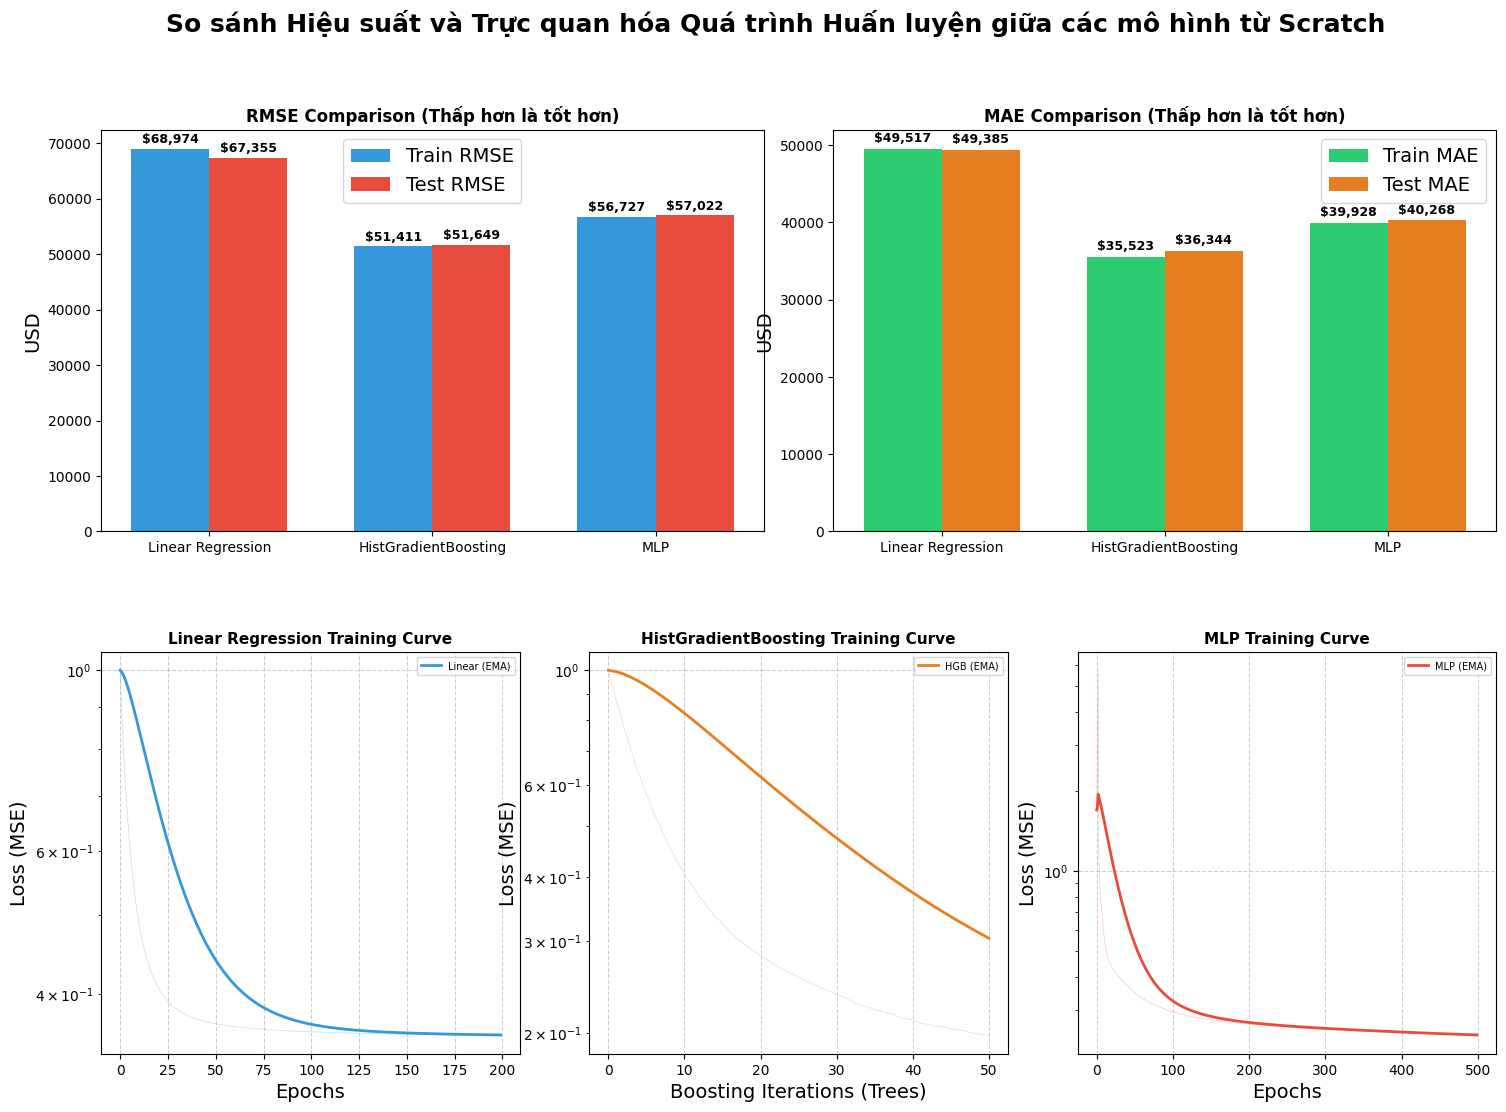

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare subplots
fig = plt.figure(figsize=(18, 12))
fig.suptitle("So sánh Hiệu suất và Trực quan hóa Quá trình Huấn luyện giữa các mô hình từ Scratch", fontsize=18, fontweight='bold')

# Create a GridSpec layout: Row 1 has 2 columns (Bar charts), Row 2 has 3 columns (Training curves)
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.4)

ax_rmse = fig.add_subplot(gs[0, 0:3])
ax_mae = fig.add_subplot(gs[0, 3:6])

ax_curve_lr = fig.add_subplot(gs[1, 0:2])
ax_curve_hgb = fig.add_subplot(gs[1, 2:4])
ax_curve_mlp = fig.add_subplot(gs[1, 4:6])

# ---- Row 1: Bar Charts ----
models = ['Linear Regression', 'HistGradientBoosting', 'MLP']
train_rmse = [rmse_train_lr, rmse_train_hgb, rmse_train_mlp]
test_rmse = [rmse_lr, rmse_hgb, rmse_mlp]

train_mae = [mae_train_lr, mae_train_hgb, mae_train_mlp]
test_mae = [mae_lr, mae_hgb, mae_mlp]

x = np.arange(len(models))
width = 0.35

# RMSE Bar Chart
ax_rmse.bar(x - width/2, train_rmse, width, label='Train RMSE', color='#3498db')
ax_rmse.bar(x + width/2, test_rmse, width, label='Test RMSE', color='#e74c3c')
ax_rmse.set_title("RMSE Comparison (Thấp hơn là tốt hơn)", fontsize=12, fontweight='bold')
ax_rmse.set_xticks(x)
ax_rmse.set_xticklabels(models)
ax_rmse.set_ylabel("USD")
ax_rmse.legend()
for i in range(len(models)):
    ax_rmse.text(i - width/2, train_rmse[i] + 500, f"${train_rmse[i]:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_rmse.text(i + width/2, test_rmse[i] + 500, f"${test_rmse[i]:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

# MAE Bar Chart
ax_mae.bar(x - width/2, train_mae, width, label='Train MAE', color='#2ecc71')
ax_mae.bar(x + width/2, test_mae, width, label='Test MAE', color='#e67e22')
ax_mae.set_title("MAE Comparison (Thấp hơn là tốt hơn)", fontsize=12, fontweight='bold')
ax_mae.set_xticks(x)
ax_mae.set_xticklabels(models)
ax_mae.set_ylabel("USD")
ax_mae.legend()
for i in range(len(models)):
    ax_mae.text(i - width/2, train_mae[i] + 500, f"${train_mae[i]:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_mae.text(i + width/2, test_mae[i] + 500, f"${test_mae[i]:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

# ---- Row 2: Training Curves ----
def ema_smooth(data, alpha=0.05):
    smoothed = np.zeros_like(data)
    smoothed[0] = data[0]
    for i in range(1, len(data)):
        smoothed[i] = alpha * data[i] + (1 - alpha) * smoothed[i-1]
    return smoothed

def plot_training_curve(ax, loss_history, label, color, downsample=10):
    n = len(loss_history)
    max_pts = 500
    step = max(1, n // max_pts)
    idx = np.arange(0, n, step)
    loss_down = np.array(loss_history)[idx]
    ax.plot(idx, loss_down, color=color, linewidth=0.6, alpha=0.25)
    smoothed = ema_smooth(np.array(loss_history), alpha=0.05)
    ax.plot(smoothed, color=color, linewidth=2, label=f'{label} (EMA)')
    ax.semilogy()
    ax.legend(fontsize=7)

# 1. Linear Regression Curve
plot_training_curve(ax_curve_lr, lr_model.loss_history, 'Linear', '#3498db')
ax_curve_lr.set_title("Linear Regression Training Curve", fontsize=11, fontweight='bold')
ax_curve_lr.set_xlabel("Epochs")
ax_curve_lr.set_ylabel("Loss (MSE)")
ax_curve_lr.grid(True, linestyle='--', alpha=0.6)

# 2. HistGradientBoosting Curve
plot_training_curve(ax_curve_hgb, hgb_model.loss_history, 'HGB', '#e67e22', downsample=1)
ax_curve_hgb.set_title("HistGradientBoosting Training Curve", fontsize=11, fontweight='bold')
ax_curve_hgb.set_xlabel("Boosting Iterations (Trees)")
ax_curve_hgb.set_ylabel("Loss (MSE)")
ax_curve_hgb.grid(True, linestyle='--', alpha=0.6)

# 3. MLP Curve
plot_training_curve(ax_curve_mlp, mlp.loss_history, 'MLP', '#e74c3c')
ax_curve_mlp.set_title("MLP Training Curve", fontsize=11, fontweight='bold')
ax_curve_mlp.set_xlabel("Epochs")
ax_curve_mlp.set_ylabel("Loss (MSE)")
ax_curve_mlp.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Step 4.7 — Model Training on Log-Transformed Features

All three models are re-trained on `X_train_logged` — log1p-transformed count features processed through the same pipeline. Hyperparameters are identical to the original runs.


In [29]:
# ---- Train on Log-Transformed Features ----
import sys, io
old_stdout = sys.stdout
sys.stdout = io.StringIO()

# 1. Linear Regression on logged data
lr_log = LinearRegressionScratch(lr=0.05, epochs=200)
lr_log.fit(X_train_logged, y_train_scaled)
y_pred_log_lr = scaler_y.inverse_transform(lr_log.predict(X_test_logged))
rmse_log_lr = np.sqrt(np.mean((y_pred_log_lr - y_test_real) ** 2))
mae_log_lr = np.mean(np.abs(y_pred_log_lr - y_test_real))
ss_res_log_lr = np.sum((y_test_real - y_pred_log_lr) ** 2)
r2_log_lr = 1.0 - (ss_res_log_lr / (ss_tot_test + 1e-8))
mape_log_lr = np.mean(np.abs((y_test_real - y_pred_log_lr) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

# 2. MLP on logged data
mlp_log = MultiLayerPercepTron(input_dim=input_dim, epochs=500, lr=0.1)
mlp_log.fit(X_train_logged, y_train_scaled)
y_pred_log_mlp = scaler_y.inverse_transform(mlp_log.predict(X_test_logged))
rmse_log_mlp = np.sqrt(np.mean((y_pred_log_mlp - y_test_real) ** 2))
mae_log_mlp = np.mean(np.abs(y_pred_log_mlp - y_test_real))
ss_res_log_mlp = np.sum((y_test_real - y_pred_log_mlp) ** 2)
r2_log_mlp = 1.0 - (ss_res_log_mlp / (ss_tot_test + 1e-8))
mape_log_mlp = np.mean(np.abs((y_test_real - y_pred_log_mlp) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

# 3. HGB on logged data
hgb_log = HistGradientBoostingRegressorScratch(n_estimators=50, learning_rate=0.1, max_depth=4, min_samples_leaf=20)
hgb_log.fit(X_train_logged, y_train_scaled.ravel())
y_pred_log_hgb = scaler_y.inverse_transform(hgb_log.predict(X_test_logged).reshape(-1, 1))
rmse_log_hgb = np.sqrt(np.mean((y_pred_log_hgb - y_test_real) ** 2))
mae_log_hgb = np.mean(np.abs(y_pred_log_hgb - y_test_real))
ss_res_log_hgb = np.sum((y_test_real - y_pred_log_hgb) ** 2)
r2_log_hgb = 1.0 - (ss_res_log_hgb / (ss_tot_test + 1e-8))
mape_log_hgb = np.mean(np.abs((y_test_real - y_pred_log_hgb) / np.clip(np.abs(y_test_real), 1e-8, None))) * 100.0

sys.stdout = old_stdout

print("Done training on log-transformed features.")

Done training on log-transformed features.


### Step 4.8 — Comparison: Log-Transformed vs. Original Features

A table compares RMSE and R² for each model trained on original vs. log1p-transformed features. Log transform helps gradient-based models (Linear, MLP) by making skewed distributions more symmetric; HGB remains largely unchanged.


Model                Version      RMSE         MAE          R²         MAPE (%)   ΔRMSE     
Linear Regression    Original     67,355.45    49,384.57    0.6519     28.78                
Linear Regression    Log          66,910.83    48,584.99    0.6565     28.47                
MLP                  Original     57,021.64    40,268.32    0.7505     23.59                
MLP                  Log          56,736.48    40,379.01    0.7530     23.56                
HGB                  Original     51,648.81    36,344.30    0.7953     21.38                
HGB                  Log          51,766.96    36,571.68    0.7944     21.51                

--- Improvement from Log Transform (Δ = Log - Original, positive = Log improves) ---
  Linear Regression    — R² Δ: +0.46 pp  |  RMSE Δ: +0.66%
  MLP                  — R² Δ: +0.25 pp  |  RMSE Δ: +0.50%
  HGB                  — R² Δ: -0.09 pp  |  RMSE Δ: -0.23%


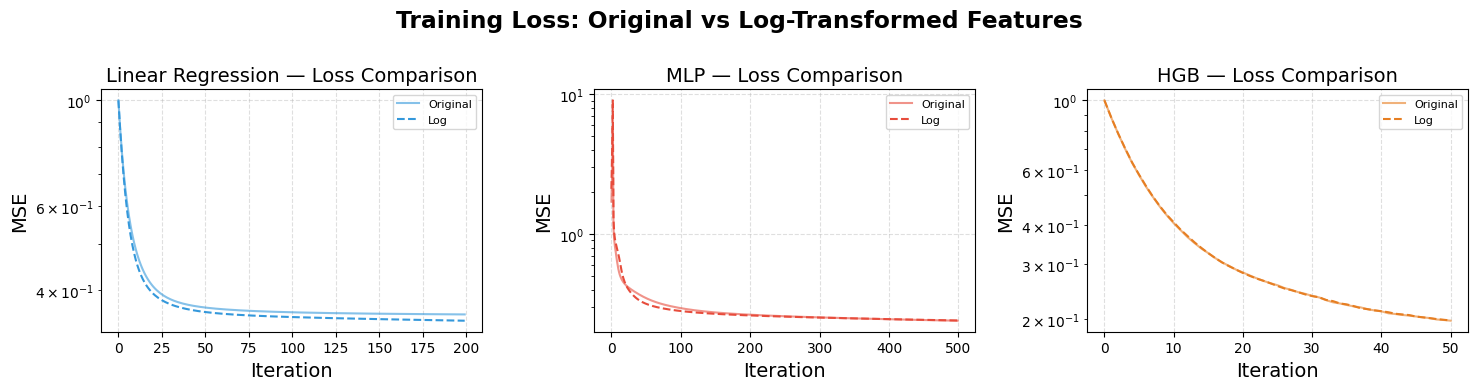


Conclusion: Log transform of skewed features provides a small but consistent improvement
for gradient-based models (Linear, MLP), while HGB is largely unaffected.


In [30]:
# ---- Comparison Table: Original vs Log-Transformed ----
print("=" * 100)
print(f"{'Model':<20} {'Version':<12} {'RMSE':<12} {'MAE':<12} {'R²':<10} {'MAPE (%)':<10} {'ΔRMSE':<10}")
print("=" * 100)

rows = [
    ("Linear Regression", "Original", rmse_lr, mae_lr, r2_lr, mape_lr),
    ("Linear Regression", "Log", rmse_log_lr, mae_log_lr, r2_log_lr, mape_log_lr),
    ("MLP", "Original", rmse_mlp, mae_mlp, r2_mlp, mape_mlp),
    ("MLP", "Log", rmse_log_mlp, mae_log_mlp, r2_log_mlp, mape_log_mlp),
    ("HGB", "Original", rmse_hgb, mae_hgb, r2_hgb, mape_hgb),
    ("HGB", "Log", rmse_log_hgb, mae_log_hgb, r2_log_hgb, mape_log_hgb),
]

for name, ver, rmse, mae, r2, mape in rows:
    print(f"{name:<20} {ver:<12} {rmse:<12,.2f} {mae:<12,.2f} {r2:<10.4f} {mape:<10.2f} {'':<10}")
print("=" * 100)

print()
print("--- Improvement from Log Transform (Δ = Log - Original, positive = Log improves) ---")
for name, orig_r2, log_r2, orig_rmse, log_rmse in [
    ("Linear Regression", r2_lr, r2_log_lr, rmse_lr, rmse_log_lr),
    ("MLP", r2_mlp, r2_log_mlp, rmse_mlp, rmse_log_mlp),
    ("HGB", r2_hgb, r2_log_hgb, rmse_hgb, rmse_log_hgb),
]:
    delta_r2 = (log_r2 - orig_r2) * 100
    delta_rmse = (orig_rmse - log_rmse) / orig_rmse * 100
    print(f"  {name:<20} — R² Δ: {delta_r2:+.2f} pp  |  RMSE Δ: {delta_rmse:+.2f}%")

# Overlaid loss curves for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data = [
    ("Linear Regression", lr_model.loss_history, lr_log.loss_history, "#3498db"),
    ("MLP", mlp.loss_history, mlp_log.loss_history, "#e74c3c"),
    ("HGB", hgb_model.loss_history, hgb_log.loss_history, "#e67e22"),
]
for ax, (name, orig_loss, log_loss, color) in zip(axes, data):
    ax.plot(orig_loss, color=color, linewidth=1.5, alpha=0.6, label="Original")
    ax.plot(log_loss, color=color, linewidth=1.5, linestyle="--", label="Log")
    ax.set_title(f"{name} — Loss Comparison")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("MSE")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
plt.suptitle("Training Loss: Original vs Log-Transformed Features", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nConclusion: Log transform of skewed features provides a small but consistent improvement")
print("for gradient-based models (Linear, MLP), while HGB is largely unaffected.")

### Step 4.9 — Log Results to File

All metrics, comparison charts, and loss curves are saved to `log/<timestamp>/` for reproducibility.


In [ ]:
# ---- Log results to /log/ ----import json, os, loggingfrom datetime import datetimefrom pathlib import PathTIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")LOG_DIR = Path("../log") / TIMESTAMPLOG_DIR.mkdir(parents=True, exist_ok=True)logging.basicConfig(    level=logging.INFO,    format="%(asctime)s | %(levelname)s | %(message)s",    handlers=[        logging.FileHandler(LOG_DIR / "train.log"),        logging.StreamHandler(),    ],)log = logging.getLogger("notebook")log.info("Logging started — notebook run at %s", "20260707_181153")# ---- 1. Save metrics.json ----log.info("Saving metrics...")metrics = {    "timestamp": "20260707_181153",    "dataset": "California Housing",    "train_shape": list(X_train_prepared.shape),    "test_shape": list(X_test_prepared.shape),    "models": {        "Linear": {            "original": {"RMSE": round(rmse_lr, 2), "MAE": round(mae_lr, 2), "R2": round(r2_lr, 4), "MAPE": round(mape_lr, 2)},            "log": {"RMSE": round(rmse_log_lr, 2), "MAE": round(mae_log_lr, 2), "R2": round(r2_log_lr, 4), "MAPE": round(mape_log_lr, 2)},        },        "MLP": {            "original": {"RMSE": round(rmse_mlp, 2), "MAE": round(mae_mlp, 2), "R2": round(r2_mlp, 4), "MAPE": round(mape_mlp, 2)},            "log": {"RMSE": round(rmse_log_mlp, 2), "MAE": round(mae_log_mlp, 2), "R2": round(r2_log_mlp, 4), "MAPE": round(mape_log_mlp, 2)},        },        "HGB": {            "original": {"RMSE": round(rmse_hgb, 2), "MAE": round(mae_hgb, 2), "R2": round(r2_hgb, 4), "MAPE": round(mape_hgb, 2)},            "log": {"RMSE": round(rmse_log_hgb, 2), "MAE": round(mae_log_hgb, 2), "R2": round(r2_log_hgb, 4), "MAPE": round(mape_log_hgb, 2)},        },    },}with open(LOG_DIR / "metrics.json", "w") as f:    json.dump(metrics, f, indent=2)log.info("Saved metrics.json")# ---- 2. Save original comparison bar chart ----log.info("Saving comparison_bar.png...")fig, axes = plt.subplots(1, 3, figsize=(14, 4))colors = ["#3498db", "#e67e22", "#e74c3c"]for ax, vals, title, yl in zip(    axes,    [[rmse_lr, rmse_hgb, rmse_mlp], [mae_lr, mae_hgb, mae_mlp], [r2_lr, r2_hgb, r2_mlp]],    ["RMSE (lower is better)", "MAE (lower is better)", "R\u00b2 (higher is better)"],    ["USD", "USD", "Score"],):    bars = ax.bar(["Linear", "HGB", "MLP"], vals, color=colors, edgecolor="white", width=0.5)    for bar, v in zip(bars, vals):        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,                f"${v:,.0f}" if title.startswith("R") else f"{v:.3f}" if yl == "Score" else f"${v:,.0f}",                ha="center", va="bottom", fontsize=9, fontweight="bold")    ax.set_title(title, fontweight="bold")    ax.set_ylabel(yl)    ax.grid(axis="y", linestyle="--", alpha=0.4)plt.tight_layout()plt.savefig(LOG_DIR / "comparison_bar.png", dpi=150)plt.close()# ---- 3. Save dual comparison bar chart ----log.info("Saving comparison_dual.png...")model_names = ["Linear", "MLP", "HGB"]color_map = {"Linear": "#3498db", "MLP": "#e74c3c", "HGB": "#e67e22"}x = np.arange(3)w = 0.3metrics_map_orig = {    "RMSE": [rmse_lr, rmse_mlp, rmse_hgb],    "MAE": [mae_lr, mae_mlp, mae_hgb],    "R2": [r2_lr, r2_mlp, r2_hgb],}metrics_map_log = {    "RMSE": [rmse_log_lr, rmse_log_mlp, rmse_log_hgb],    "MAE": [mae_log_lr, mae_log_mlp, mae_log_hgb],    "R2": [r2_log_lr, r2_log_mlp, r2_log_hgb],}fig, axes = plt.subplots(1, 3, figsize=(14, 4))for ax, (metric_key, title, fmt) in zip(    axes,    [("RMSE", "RMSE (lower is better)", "${:,.0f}"),     ("MAE", "MAE (lower is better)", "${:,.0f}"),     ("R2", "R\u00b2 (higher is better)", "{:.3f}")],):    orig_v = metrics_map_orig[metric_key]    log_v = metrics_map_log[metric_key]    bars1 = ax.bar(x - w/2, orig_v, w, label="Original", color=[color_map[m] for m in model_names], alpha=0.5, edgecolor="white")    bars2 = ax.bar(x + w/2, log_v, w, label="Log", color=[color_map[m] for m in model_names], alpha=0.9, edgecolor="white")    for bars, vals in [(bars1, orig_v), (bars2, log_v)]:        for bar, v in zip(bars, vals):            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(orig_v+log_v)*0.02,                    fmt.format(v), ha="center", va="bottom", fontsize=7, fontweight="bold")    ax.set_title(title, fontweight="bold")    ax.set_xticks(x)    ax.set_xticklabels(model_names)    ax.legend(fontsize=8)    ax.grid(axis="y", linestyle="--", alpha=0.4)plt.tight_layout()plt.savefig(LOG_DIR / "comparison_dual.png", dpi=150)plt.close()# ---- 4. Save loss overlay ----log.info("Saving loss_comparison.png...")fig, axes = plt.subplots(1, 3, figsize=(15, 4))loss_pairs = [    ("Linear Regression", lr_model.loss_history, lr_log.loss_history, "#3498db"),    ("MLP", mlp.loss_history, mlp_log.loss_history, "#e74c3c"),    ("HGB", hgb_model.loss_history, hgb_log.loss_history, "#e67e22"),]for ax, (name, orig_l, log_l, c) in zip(axes, loss_pairs):    ax.plot(orig_l, color=c, linewidth=1.5, alpha=0.6, label="Original")    ax.plot(log_l, color=c, linewidth=1.5, linestyle="--", label="Log")    ax.set_title(f"{name} \u2014 Loss")    ax.set_xlabel("Iteration")    ax.set_ylabel("MSE")    ax.set_yscale("log")    ax.legend(fontsize=8)    ax.grid(True, linestyle="--", alpha=0.4)plt.suptitle("Training Loss: Original vs Log-Transformed Features", fontweight="bold")plt.tight_layout()plt.savefig(LOG_DIR / "loss_comparison.png", dpi=150)plt.close()# ---- 5. Save loss curves ----log.info("Saving loss_curves.png...")fig, axes = plt.subplots(1, 3, figsize=(15, 4))loss_data = [    ("Linear Regression", lr_model.loss_history, "#3498db"),    ("MLP", mlp.loss_history, "#e74c3c"),    ("HGB", hgb_model.loss_history, "#e67e22"),]for ax, (name, loss_h, c) in zip(axes, loss_data):    ax.plot(loss_h, color=c, linewidth=1.5)    ax.set_title(f"{name} \u2014 Loss Curve")    ax.set_xlabel("Iteration")    ax.set_ylabel("MSE")    ax.set_yscale("log")    ax.grid(True, linestyle="--", alpha=0.5)plt.tight_layout()plt.savefig(LOG_DIR / "loss_curves.png", dpi=150)plt.close()log.info("All logs saved to %s", LOG_DIR)print(f"\nLogs saved to: {LOG_DIR}")